# SLD Component Detection — D-FINE Inference Notebook

**Before running:** upload `best_stg2.pth` when stage 2 is the checkpoint you want to evaluate; the notebook falls back to `best_stg1.pth` only when stage 2 is absent.

D-FINE saves separate stage-1 and stage-2 best checkpoints; this notebook prefers `best_stg2.pth` and prints the selected file and epoch after loading.

**Two important checks before trusting results:**
- This notebook **reconstructs** the model architecture config from your training log output, since the original custom training YAML wasn't available here. If you still have that file (the one passed to `train.py -c ...`), upload it and point `CONFIG_PATH` at it in Step 3 instead — that guarantees an exact match.
- Your training log showed `remap_mscoco_category: True`. That flag is meant for real MS-COCO category IDs, not custom datasets — if detections come back with obviously wrong/scrambled class names, this is the first thing to check (would need a retrain with it set to `False`).

**Two modes:**
- Mode 1: Full image (fast)
- Mode 2: 4×4 tiled with overlap (recommended for large SLD sheets)


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 1 — Install D-FINE
# ══════════════════════════════════════════════════════
import os

if not os.path.exists('/content/D-FINE'):
    !git clone --depth 1 https://github.com/Peterande/D-FINE.git /content/D-FINE

%cd /content/D-FINE
!pip install -q -r requirements.txt
!pip install -q supervision Pillow

import importlib
for pkg in ['torch', 'torchvision', 'supervision']:
    m = importlib.import_module(pkg)
    print(f'ok {pkg} {getattr(m, "__version__", "")}')


Cloning into '/content/D-FINE'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 189 (delta 42), reused 54 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (189/189), 171.99 KiB | 1.46 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/D-FINE
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 10.9 MB/s eta 0:00:00
ok torch 2.11.0+cu128
ok torchvision 0.26.0+cu128
ok supervision 0.29.1


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 2 — Config
# ══════════════════════════════════════════════════════
import os

DFINE_WEIGHTS_PATH  = next((p for p in ['/content/best_stg2.pth', '/content/best_stg1.pth'] if os.path.exists(p)), '/content/best_stg1.pth')
RFDETR_WEIGHTS_PATH = '/content/checkpoint_best_regular.pth'

DFINE_NUM_CLASSES = 30
RFDETR_NUM_CLASSES = 10
RESOLUTION    = 640
CONFIDENCE    = 0.20
GRID_SIZE     = 4
OVERLAP       = 0.20
IOU_THRESHOLD = 0.50

DFINE_CLASS_NAMES = [
    'ACB', 'ATS', 'Ammeter', 'UNKNOWN_ID_4', 'CIRCUIT BREAKER',
    'CURRENT TRANSFORMER', 'Circuit Breaker 2', 'Contractor 1',
    'DIGITAL METER', 'Digital Power Meter', 'EARTH LEAKAGE RELAY',
    'EMS', 'Earth Fault Relay', 'FUSE 1', 'FUSE 2',
    'HRC FUSE WITH BLOWN FUSE INDICATOR', 'ISOLATOR',
    'MAXIMUM DEMAND AMMETER', 'Over current Relay', 'PHASE INDICATOR LIGHTS',
    'Power Quality Meter', 'RCCB', 'SELECTOR SWITCH', 'SHUNT TRIP',
    'SINGLE PHASE UNFUSED TAP OFF UNIT', 'SURGE ARRESTOR 1', 'UNKNOWN_ID_27',
    'TIME DELAY RELAY', 'VOLTMETER', 'ZERO PHASE SEQUENCE CURRENT TRANSFORMER',
]
RFDETR_CLASS_NAMES = [
    'CIRCUIT BREAKER',
    'CURRENT TRANSFORMER',
    'DIGITAL EARTH LEAKAGE RELAY',
    'EARTH LEAKAGE RELAY',
    'HRC FUSE WITH BLOWN FUSE INDICATOR',
    'ISOLATOR',
    'PHASE INDICATOR LIGHTS',
    'SINGLE PHASE UNFUSED TAP OFF UNIT',
    'TIME DELAY RELAY',
    'ZERO PHASE SEQUENCE CURRENT TRANSFORMER',
]

assert os.path.exists(DFINE_WEIGHTS_PATH),  f'D-FINE weights not found:  {DFINE_WEIGHTS_PATH}'
assert os.path.exists(RFDETR_WEIGHTS_PATH), f'RF-DETR weights not found: {RFDETR_WEIGHTS_PATH}'
assert len(DFINE_CLASS_NAMES) == DFINE_NUM_CLASSES
assert len(RFDETR_CLASS_NAMES) == RFDETR_NUM_CLASSES

print('=' * 60)
print(f'D-FINE  Weights : {DFINE_WEIGHTS_PATH}')
print(f'RF-DETR Weights : {RFDETR_WEIGHTS_PATH}')
print(f'D-FINE classes  : {DFINE_NUM_CLASSES}')
print(f'RF-DETR classes : {RFDETR_NUM_CLASSES}')
print(f'Resolution      : {RESOLUTION}')
print(f'Confidence      : {CONFIDENCE}')
print(f'D-FINE classes  : {DFINE_CLASS_NAMES}')
print(f'RF-DETR classes : {RFDETR_CLASS_NAMES}')
print('=' * 60)

D-FINE  Weights : /content/best_stg1.pth
RF-DETR Weights : /content/checkpoint_best_regular.pth
Num Classes     : 10
Resolution      : 640
Confidence      : 0.2
Classes         : ['CIRCUIT BREAKER', 'CURRENT TRANSFORMER', 'DIGITAL EARTH LEAKAGE RELAY', 'EARTH LEAKAGE RELAY', 'HRC FUSE WITH BLOWN FUSE INDICATOR', 'ISOLATOR', 'PHASE INDICATOR LIGHTS', 'SINGLE PHASE UNFUSED TAP OFF UNIT', 'TIME DELAY RELAY', 'ZERO PHASE SEQUENCE CURRENT TRANSFORMER']


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 3 — Build model from config + load checkpoint
# ══════════════════════════════════════════════════════
import sys
sys.path.append('/content/D-FINE')

import torch
import torch.nn as nn

# Reconstructed from your training log's resolved cfg (D-FINE-X / HGNetv2-B5).
# If you still have your ORIGINAL custom training yaml (the one passed to
# `train.py -c ...`), upload it instead and set CONFIG_PATH to that file —
# that guarantees an exact architecture match rather than a reconstruction.
RECONSTRUCTED_CFG = f'''
task: detection
model: DFINE
postprocessor: DFINEPostProcessor
num_classes: {DFINE_NUM_CLASSES}
eval_spatial_size: [{RESOLUTION}, {RESOLUTION}]
use_focal_loss: True

DFINE:
  backbone: HGNetv2
  encoder: HybridEncoder
  decoder: DFINETransformer

HGNetv2:
  name: B5
  return_idx: [1, 2, 3]
  freeze_stem_only: True
  freeze_at: 0
  freeze_norm: True
  pretrained: False

HybridEncoder:
  in_channels: [512, 1024, 2048]
  feat_strides: [8, 16, 32]
  hidden_dim: 384
  use_encoder_idx: [2]
  num_encoder_layers: 1
  nhead: 8
  dim_feedforward: 2048
  dropout: 0.0
  enc_act: 'gelu'
  expansion: 1.0
  depth_mult: 1
  act: 'silu'

DFINETransformer:
  feat_channels: [384, 384, 384]
  feat_strides: [8, 16, 32]
  hidden_dim: 256
  num_levels: 3
  num_layers: 6
  eval_idx: -1
  num_queries: 300
  num_denoising: 100
  label_noise_ratio: 0.5
  box_noise_scale: 1.0
  layer_scale: 1
  num_points: [3, 6, 3]
  cross_attn_method: default
  query_select_method: default
  reg_max: 32
  reg_scale: 8

DFINEPostProcessor:
  num_top_queries: 300
'''

CONFIG_PATH = '/content/dfine_inference_config.yml'
with open(CONFIG_PATH, 'w') as f:
    f.write(RECONSTRUCTED_CFG)

from src.core import YAMLConfig

cfg = YAMLConfig(CONFIG_PATH, resume=DFINE_WEIGHTS_PATH)

checkpoint = torch.load(DFINE_WEIGHTS_PATH, map_location='cpu', weights_only=False)
print(f'Checkpoint metadata: last_epoch={checkpoint.get("last_epoch", "unknown")} date={checkpoint.get("date", "unknown")}')
if 'ema' in checkpoint:
    state = checkpoint['ema']['module']
elif 'model' in checkpoint:
    state = checkpoint['model']
else:
    state = checkpoint  # assume raw state_dict

cfg.model.load_state_dict(state)

class DFINEInferModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.model = cfg.model.deploy()
        self.postprocessor = cfg.postprocessor.deploy()

    def forward(self, images, orig_target_sizes):
        outputs = self.model(images)
        outputs = self.postprocessor(outputs, orig_target_sizes)
        return outputs  # (labels, boxes, scores)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = DFINEInferModel(cfg).to(device).eval()
print(f'Device: {device}')
print('D-FINE model loaded from', DFINE_WEIGHTS_PATH)


Device: cuda
D-FINE model loaded from /content/best_stg1.pth


In [ ]:
# ══════════════════════════════════════════════════════
# STEP 4 — Helpers (D-FINE version — no background class to skip)
# ══════════════════════════════════════════════════════
from PIL import Image
import numpy as np
import supervision as sv
import torchvision.transforms as T

# Matches training pipeline exactly: plain resize to (RESOLUTION, RESOLUTION)
# (NOT aspect-ratio-preserving — D-FINE's own Resize op squeezes the image),
# then scale to [0,1]. No mean/std normalization — your training config's
# ConvertPILImage step doesn't apply one either.
transform = T.Compose([
    T.Resize((RESOLUTION, RESOLUTION)),
    T.ToTensor(),
])

@torch.no_grad()
def run_inference(pil_image):
    W, H = pil_image.size
    img_t = transform(pil_image.convert('RGB')).unsqueeze(0).to(device)
    orig_size = torch.tensor([[W, H]], device=device)
    labels, boxes, scores = model(img_t, orig_size)
    labels = labels[0].cpu().numpy().astype(int)
    boxes  = boxes[0].cpu().numpy().astype(np.float32)
    scores = scores[0].cpu().numpy().astype(np.float32)
    keep = scores >= CONFIDENCE
    return sv.Detections(xyxy=boxes[keep], confidence=scores[keep], class_id=labels[keep])

def draw_detections(pil_image, detections, class_names=DFINE_CLASS_NAMES):
    if len(detections) == 0:
        return pil_image

    box_annotator   = sv.BoxAnnotator(thickness=3)
    label_annotator = sv.LabelAnnotator(text_scale=0.6, text_thickness=2)

    labels = [
        f'{class_names[int(c)] if int(c) < len(class_names) else f"class_{c}"}  {s:.2f}'
        for c, s in zip(detections.class_id, detections.confidence)
        # no background class to skip here — every id in D-FINE is a real class
    ]

    img_np = np.array(pil_image)
    img_np = box_annotator.annotate(img_np, detections)
    img_np = label_annotator.annotate(img_np, detections, labels=labels)
    return Image.fromarray(img_np)

def tile_image(image, grid_size=GRID_SIZE, overlap=OVERLAP):
    W, H = image.size
    tile_w = W // grid_size
    tile_h = H // grid_size
    step_x = max(1, int(tile_w * (1 - overlap)))
    step_y = max(1, int(tile_h * (1 - overlap)))
    positions_x = [gx * step_x for gx in range(grid_size)]
    positions_y = [gy * step_y for gy in range(grid_size)]
    if grid_size > 1:
        positions_x[-1] = W - tile_w
        positions_y[-1] = H - tile_h

    tiles = []
    for y in positions_y:
        for x in positions_x:
            x_end = min(x + tile_w, W)
            y_end = min(y + tile_h, H)
            tile = image.crop((x, y, x_end, y_end))
            tiles.append((tile, x, y))
    return tiles

def merge_detections(tile_results, orig_W, orig_H):
    all_boxes, all_scores, all_classes = [], [], []
    for det, x_off, y_off in tile_results:
        if len(det) == 0:
            continue
        boxes = det.xyxy.copy()
        boxes[:, [0, 2]] += x_off
        boxes[:, [1, 3]] += y_off
        boxes[:, 0] = np.clip(boxes[:, 0], 0, orig_W)
        boxes[:, 1] = np.clip(boxes[:, 1], 0, orig_H)
        boxes[:, 2] = np.clip(boxes[:, 2], 0, orig_W)
        boxes[:, 3] = np.clip(boxes[:, 3], 0, orig_H)
        all_boxes.append(boxes)
        all_scores.append(det.confidence)
        all_classes.append(det.class_id)
    if not all_boxes:
        return sv.Detections.empty()
    merged = sv.Detections(
        xyxy       = np.vstack(all_boxes),
        confidence = np.concatenate(all_scores),
        class_id   = np.concatenate(all_classes).astype(int)
    )
    return merged.with_nms(threshold=IOU_THRESHOLD)

print('Helpers ready')


Helpers ready


In [ ]:
# ══════════════════════════════════════════════════════
# INSTALL — RF-DETR
# ══════════════════════════════════════════════════════
!pip install rfdetr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.3/406.3 kB 12.1 MB/s eta 0:00:00


In [ ]:
# ══════════════════════════════════════════════════════
# MODEL LOADING — D-FINE + RF-DETR
# ══════════════════════════════════════════════════════
from rfdetr import RFDETRLarge

# ── D-FINE (keep your existing load code, just rename the fn) ──
# ... your existing dfine model load code here ...

def run_inference_dfine(image):
    # your existing run_inference() body here unchanged
    return run_inference(image)   # or inline it directly

# ── RF-DETR ───────────────────────────────────────────
print('Loading RF-DETR...')
rfdetr_model = RFDETRLarge(
    pretrain_weights=RFDETR_WEIGHTS_PATH,
    num_classes=RFDETR_NUM_CLASSES
)
print('RF-DETR loaded.')

def run_inference_rfdetr(image):
    return rfdetr_model.predict(image, threshold=CONFIDENCE)

[2026-06-30 05:16:01] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-30 05:16:01] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


Loading RF-DETR...


[2026-06-30 05:16:01] [WARNING] rf-detr - Checkpoint has 11 classes but model is configured for 10. The detection head will be re-initialized to 10 classes.
[2026-06-30 05:16:01] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[2026-06-30 05:16:01] [WARNING] rf-detr - Pretrained weights at '/content/checkpoint_best_regular.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.


RF-DETR loaded.


Upload your SLD image (JPG or PNG)...


Saving image.jpg to image.jpg
Image: image.jpg  |  7021 x 4967 px


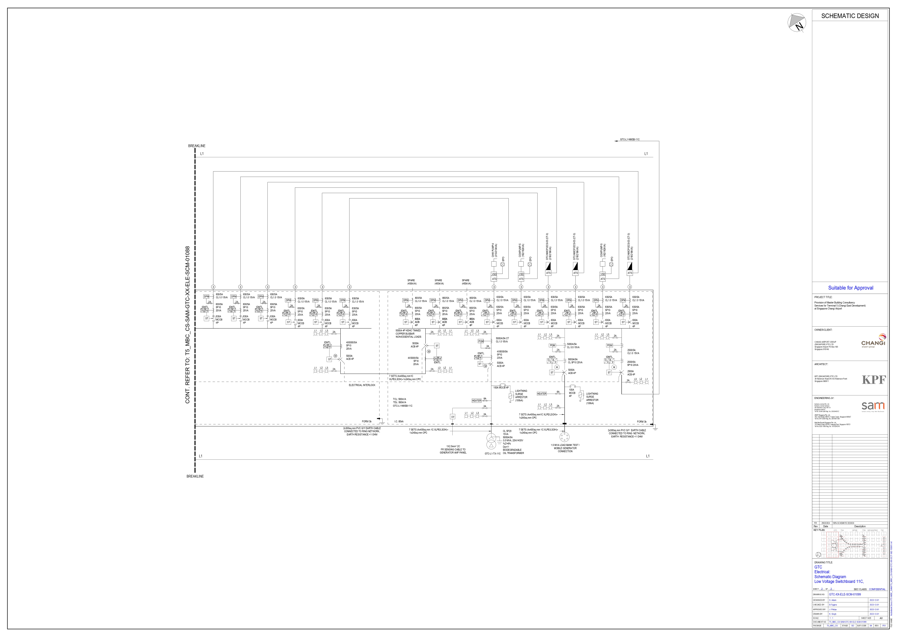

In [ ]:
# ══════════════════════════════════════════════════════
# STEP 5 — Upload test image
# ══════════════════════════════════════════════════════
from google.colab import files
from IPython.display import display
import io

print('Upload your SLD image (JPG or PNG)...')
uploaded   = files.upload()
img_name   = list(uploaded.keys())[0]
test_image = Image.open(io.BytesIO(uploaded[img_name])).convert('RGB')
W, H       = test_image.size
print(f'Image: {img_name}  |  {W} x {H} px')
thumb = test_image.copy()
thumb.thumbnail((900, 900))
display(thumb)


Total tiles: 25 (5x5, 20% overlap)

--- D-FINE 5x5 ---
  Tile 01/25 at (0,0) => 0 detections
  Tile 02/25 at (1123,0) => 0 detections
  Tile 03/25 at (2246,0) => 0 detections
  Tile 04/25 at (3369,0) => 0 detections
  Tile 05/25 at (4492,0) => 0 detections
  Tile 06/25 at (0,794) => 0 detections
  Tile 07/25 at (1123,794) => 0 detections
  Tile 08/25 at (2246,794) => 0 detections
  Tile 09/25 at (3369,794) => 0 detections
  Tile 10/25 at (4492,794) => 0 detections
  Tile 11/25 at (0,1588) => 0 detections
  Tile 12/25 at (1123,1588) => 24 detections
  Tile 13/25 at (2246,1588) => 22 detections
  Tile 14/25 at (3369,1588) => 21 detections
  Tile 15/25 at (4492,1588) => 6 detections
  Tile 16/25 at (0,2382) => 0 detections
  Tile 17/25 at (1123,2382) => 18 detections
  Tile 18/25 at (2246,2382) => 27 detections
  Tile 19/25 at (3369,2382) => 42 detections
  Tile 20/25 at (4492,2382) => 17 detections
  Tile 21/25 at (0,3176) => 0 detections
  Tile 22/25 at (1123,3176) => 0 detections
  Til

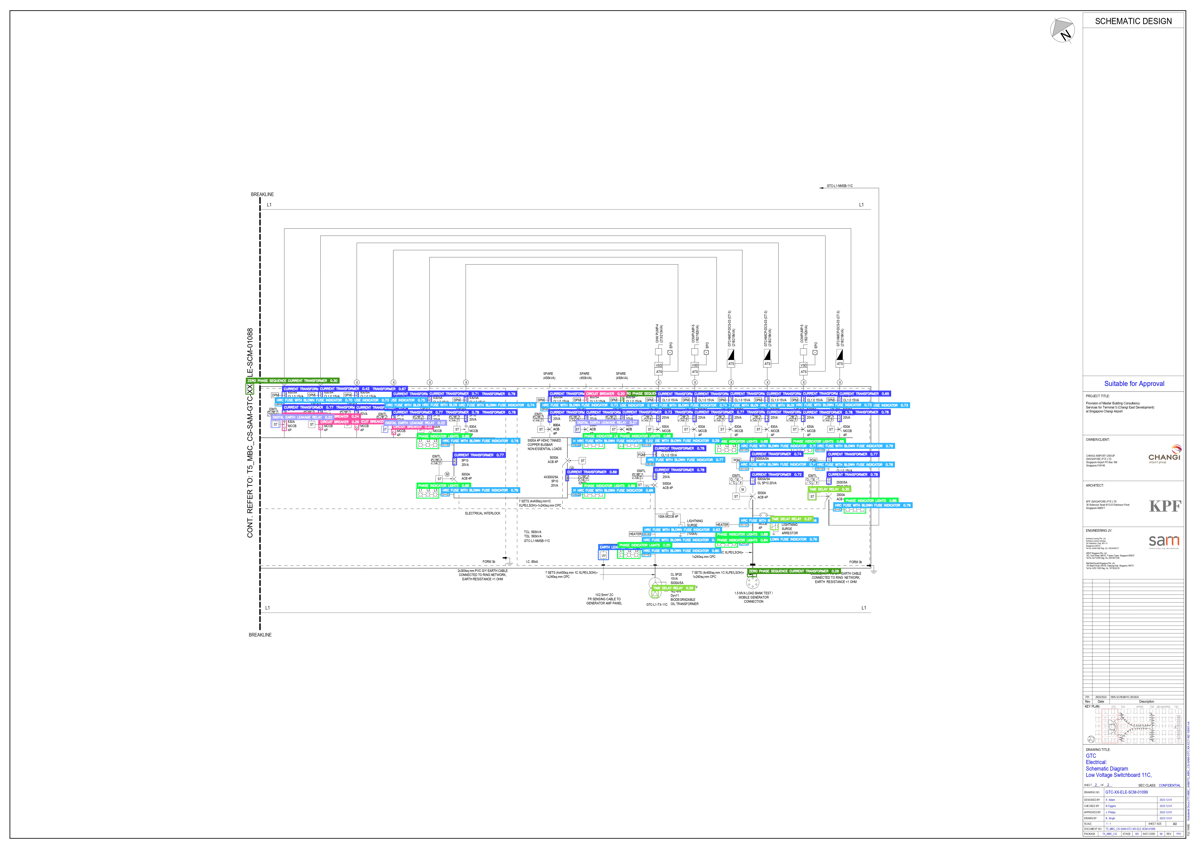


--- RF-DETR 5x5 ---
  Tile 01/25 at (0,0) => 0 detections
  Tile 02/25 at (1123,0) => 0 detections
  Tile 03/25 at (2246,0) => 0 detections
  Tile 04/25 at (3369,0) => 0 detections
  Tile 05/25 at (4492,0) => 0 detections
  Tile 06/25 at (0,794) => 0 detections
  Tile 07/25 at (1123,794) => 0 detections
  Tile 08/25 at (2246,794) => 0 detections
  Tile 09/25 at (3369,794) => 0 detections
  Tile 10/25 at (4492,794) => 0 detections
  Tile 11/25 at (0,1588) => 0 detections
  Tile 12/25 at (1123,1588) => 0 detections
  Tile 13/25 at (2246,1588) => 0 detections
  Tile 14/25 at (3369,1588) => 0 detections
  Tile 15/25 at (4492,1588) => 1 detections
  Tile 16/25 at (0,2382) => 0 detections
  Tile 17/25 at (1123,2382) => 1 detections
  Tile 18/25 at (2246,2382) => 5 detections
  Tile 19/25 at (3369,2382) => 10 detections
  Tile 20/25 at (4492,2382) => 1 detections
  Tile 21/25 at (0,3176) => 0 detections
  Tile 22/25 at (1123,3176) => 0 detections
  Tile 23/25 at (2246,3176) => 0 detections
 

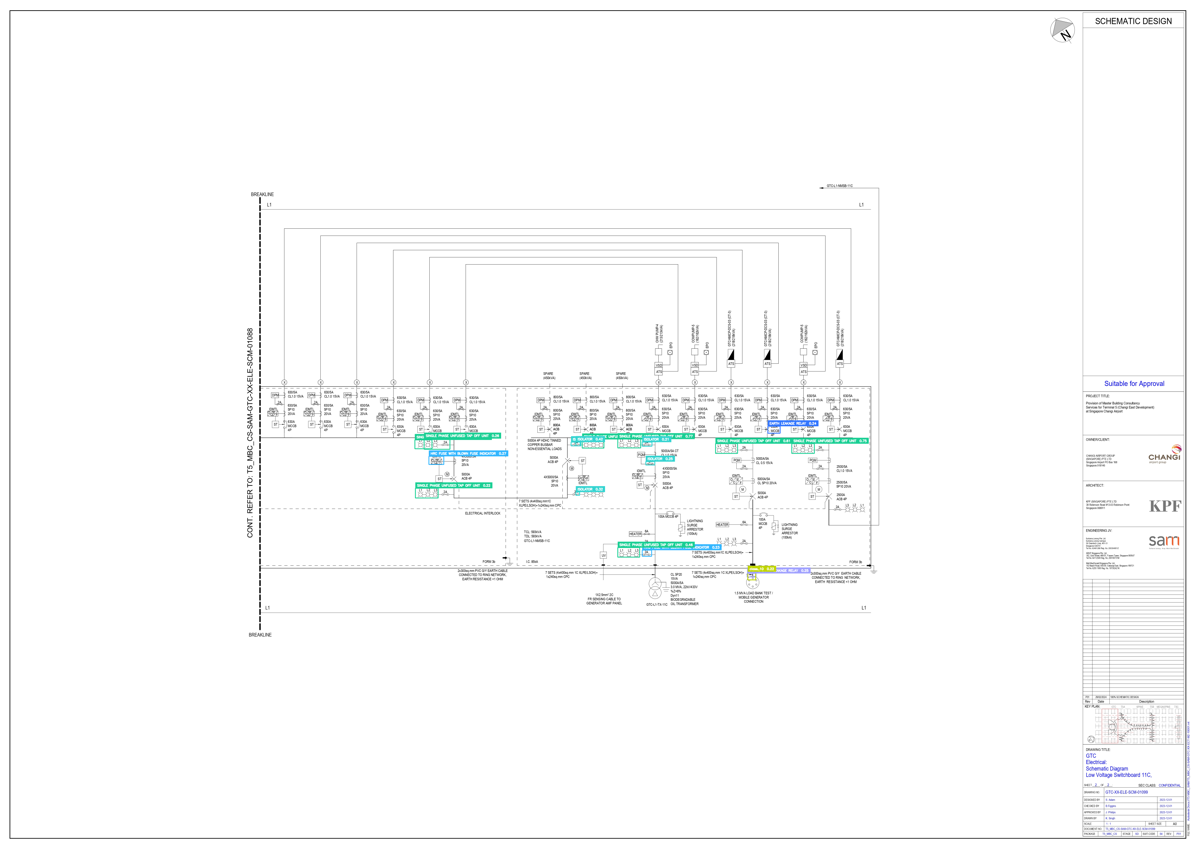

In [ ]:
# ══════════════════════════════════════════════════════
# STEP 6 — MODE 1: Tiled 5x5 — D-FINE + RF-DETR
# ══════════════════════════════════════════════════════
GRID_SIZE_5 = 5
W, H = test_image.size
tiles5 = tile_image(test_image, grid_size=GRID_SIZE_5, overlap=OVERLAP)
print(f'Total tiles: {len(tiles5)} ({GRID_SIZE_5}x{GRID_SIZE_5}, {int(OVERLAP*100)}% overlap)\n')

# ── D-FINE 5x5 ───────────────────────────────────────
print('--- D-FINE 5x5 ---')
tile_results_dfine5 = []
for i, (tile, x_off, y_off) in enumerate(tiles5):
    det = run_inference_dfine(tile)
    tile_results_dfine5.append((det, x_off, y_off))
    print(f'  Tile {i+1:02d}/{len(tiles5)} at ({x_off},{y_off}) => {len(det)} detections')
det_dfine_5x5 = merge_detections(tile_results_dfine5, W, H)
print(f'After NMS: {len(det_dfine_5x5)} detections')
for i,(box,score,cls) in enumerate(zip(det_dfine_5x5.xyxy, det_dfine_5x5.confidence, det_dfine_5x5.class_id)):
    name = DFINE_CLASS_NAMES[int(cls)] if int(cls) < len(DFINE_CLASS_NAMES) else f'class_{cls}'
    print(f'  [{i+1}] {name}  conf={score:.3f}  box=[{int(box[0])},{int(box[1])},{int(box[2])},{int(box[3])}]')

result_dfine_5x5 = draw_detections(test_image, det_dfine_5x5)
out = result_dfine_5x5.copy(); out.thumbnail((1200,1200))
print('\nD-FINE 5x5 result:'); display(out)

# ── RF-DETR 5x5 ──────────────────────────────────────
print('\n--- RF-DETR 5x5 ---')
tile_results_rfdetr5 = []
for i, (tile, x_off, y_off) in enumerate(tiles5):
    det = run_inference_rfdetr(tile)
    tile_results_rfdetr5.append((det, x_off, y_off))
    print(f'  Tile {i+1:02d}/{len(tiles5)} at ({x_off},{y_off}) => {len(det)} detections')
det_rfdetr_5x5 = merge_detections(tile_results_rfdetr5, W, H)
print(f'After NMS: {len(det_rfdetr_5x5)} detections')
for i,(box,score,cls) in enumerate(zip(det_rfdetr_5x5.xyxy, det_rfdetr_5x5.confidence, det_rfdetr_5x5.class_id)):
    name = RFDETR_CLASS_NAMES[int(cls)] if int(cls) < len(RFDETR_CLASS_NAMES) else f'class_{cls}'
    print(f'  [{i+1}] {name}  conf={score:.3f}  box=[{int(box[0])},{int(box[1])},{int(box[2])},{int(box[3])}]')

result_rfdetr_5x5 = draw_detections(test_image, det_rfdetr_5x5, RFDETR_CLASS_NAMES)
out = result_rfdetr_5x5.copy(); out.thumbnail((1200,1200))
print('\nRF-DETR 5x5 result:'); display(out)

Total tiles: 16 (4x4, 20% overlap)

--- D-FINE 4x4 ---
  Tile 01/16 at (0,0) => 0 detections
  Tile 02/16 at (1404,0) => 0 detections
  Tile 03/16 at (2808,0) => 0 detections
  Tile 04/16 at (4212,0) => 0 detections
  Tile 05/16 at (0,992) => 0 detections
  Tile 06/16 at (1404,992) => 0 detections
  Tile 07/16 at (2808,992) => 0 detections
  Tile 08/16 at (4212,992) => 0 detections
  Tile 09/16 at (0,1984) => 4 detections
  Tile 10/16 at (1404,1984) => 25 detections
  Tile 11/16 at (2808,1984) => 48 detections
  Tile 12/16 at (4212,1984) => 32 detections
  Tile 13/16 at (0,2976) => 0 detections
  Tile 14/16 at (1404,2976) => 0 detections
  Tile 15/16 at (2808,2976) => 12 detections
  Tile 16/16 at (4212,2976) => 8 detections
After NMS: 84 detections
  [1] PHASE INDICATOR LIGHTS  conf=0.885  box=[2437,2566,2568,2625]
  [2] PHASE INDICATOR LIGHTS  conf=0.883  box=[2434,2855,2569,2914]
  [3] HRC FUSE WITH BLOWN FUSE INDICATOR  conf=0.783  box=[2579,2885,2629,2903]
  [4] HRC FUSE WITH BLOW

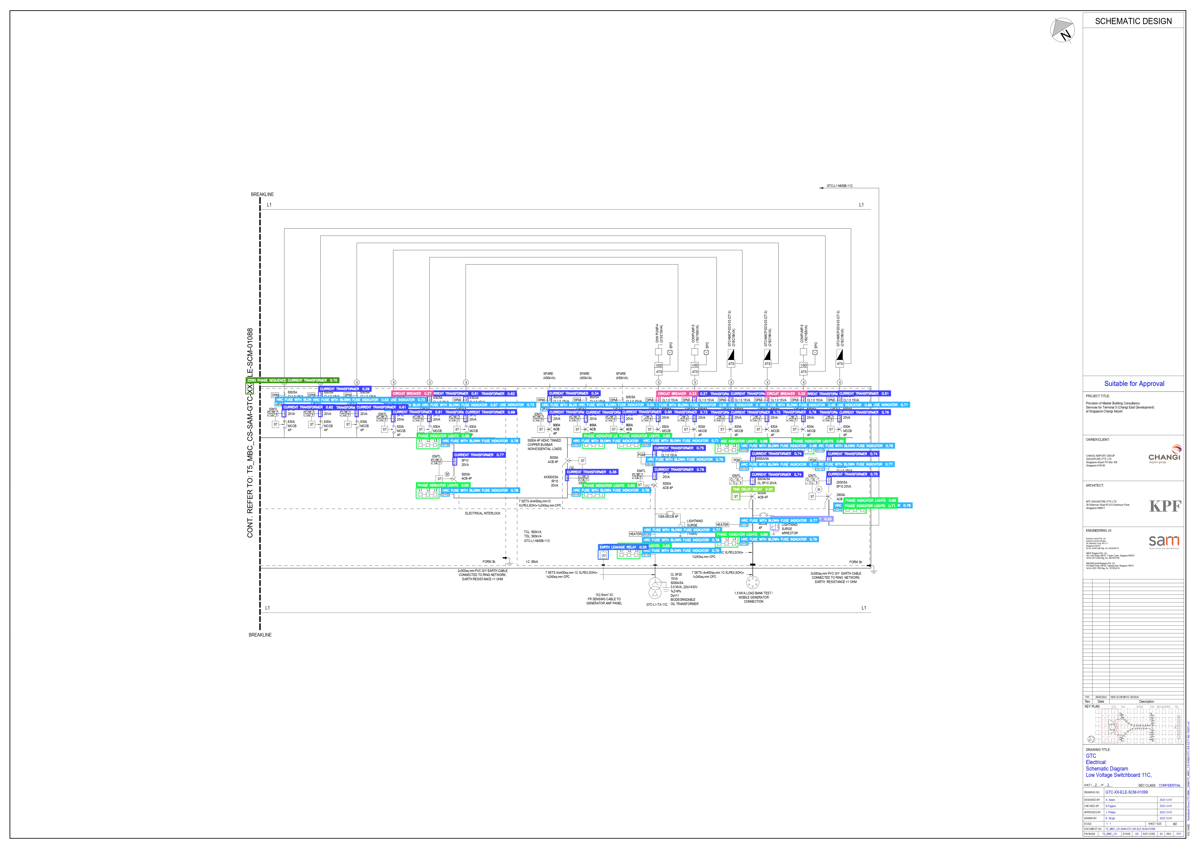


--- RF-DETR 4x4 ---
  Tile 01/16 at (0,0) => 0 detections
  Tile 02/16 at (1404,0) => 0 detections
  Tile 03/16 at (2808,0) => 0 detections
  Tile 04/16 at (4212,0) => 0 detections
  Tile 05/16 at (0,992) => 0 detections
  Tile 06/16 at (1404,992) => 0 detections
  Tile 07/16 at (2808,992) => 0 detections
  Tile 08/16 at (4212,992) => 1 detections
  Tile 09/16 at (0,1984) => 0 detections
  Tile 10/16 at (1404,1984) => 3 detections
  Tile 11/16 at (2808,1984) => 7 detections
  Tile 12/16 at (4212,1984) => 2 detections
  Tile 13/16 at (0,2976) => 0 detections
  Tile 14/16 at (1404,2976) => 0 detections
  Tile 15/16 at (2808,2976) => 5 detections
  Tile 16/16 at (4212,2976) => 1 detections
After NMS: 17 detections
  [1] class_10  conf=0.210  box=[4257,2211,4300,2233]
  [2] HRC FUSE WITH BLOWN FUSE INDICATOR  conf=0.466  box=[2695,2764,2767,2807]
  [3] SINGLE PHASE UNFUSED TAP OFF UNIT  conf=0.307  box=[2485,2565,2618,2626]
  [4] SINGLE PHASE UNFUSED TAP OFF UNIT  conf=0.256  box=[2430,28

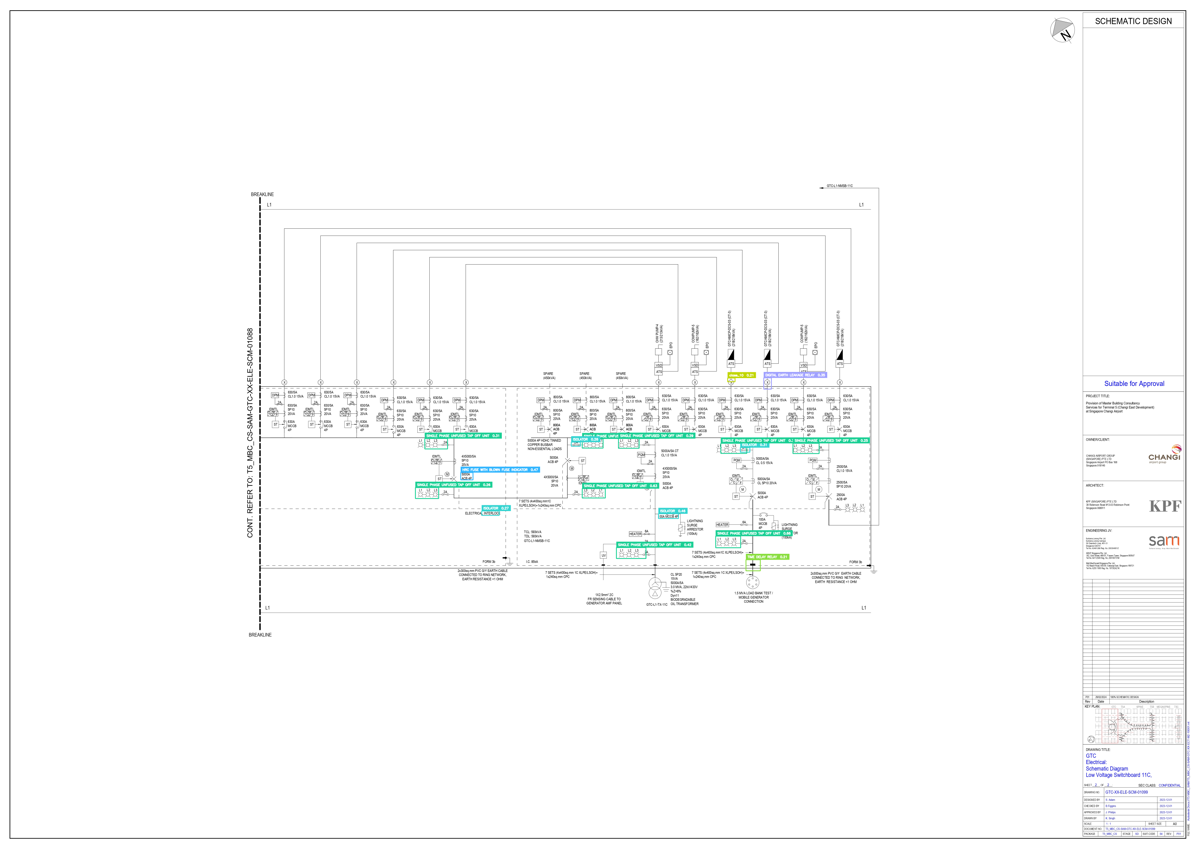

In [ ]:
# ══════════════════════════════════════════════════════
# STEP 7 — MODE 2: Tiled 4x4 — D-FINE + RF-DETR
# ══════════════════════════════════════════════════════
W, H = test_image.size
tiles4 = tile_image(test_image, grid_size=GRID_SIZE, overlap=OVERLAP)
print(f'Total tiles: {len(tiles4)} ({GRID_SIZE}x{GRID_SIZE}, {int(OVERLAP*100)}% overlap)\n')

# ── D-FINE 4x4 ───────────────────────────────────────
print('--- D-FINE 4x4 ---')
tile_results_dfine4 = []
for i, (tile, x_off, y_off) in enumerate(tiles4):
    det = run_inference_dfine(tile)
    tile_results_dfine4.append((det, x_off, y_off))
    print(f'  Tile {i+1:02d}/{len(tiles4)} at ({x_off},{y_off}) => {len(det)} detections')
det_dfine_4x4 = merge_detections(tile_results_dfine4, W, H)
print(f'After NMS: {len(det_dfine_4x4)} detections')
for i,(box,score,cls) in enumerate(zip(det_dfine_4x4.xyxy, det_dfine_4x4.confidence, det_dfine_4x4.class_id)):
    name = DFINE_CLASS_NAMES[int(cls)] if int(cls) < len(DFINE_CLASS_NAMES) else f'class_{cls}'
    print(f'  [{i+1}] {name}  conf={score:.3f}  box=[{int(box[0])},{int(box[1])},{int(box[2])},{int(box[3])}]')

result_dfine_4x4 = draw_detections(test_image, det_dfine_4x4)
out = result_dfine_4x4.copy(); out.thumbnail((1200,1200))
print('\nD-FINE 4x4 result:'); display(out)

# ── RF-DETR 4x4 ──────────────────────────────────────
print('\n--- RF-DETR 4x4 ---')
tile_results_rfdetr4 = []
for i, (tile, x_off, y_off) in enumerate(tiles4):
    det = run_inference_rfdetr(tile)
    tile_results_rfdetr4.append((det, x_off, y_off))
    print(f'  Tile {i+1:02d}/{len(tiles4)} at ({x_off},{y_off}) => {len(det)} detections')
det_rfdetr_4x4 = merge_detections(tile_results_rfdetr4, W, H)
print(f'After NMS: {len(det_rfdetr_4x4)} detections')
for i,(box,score,cls) in enumerate(zip(det_rfdetr_4x4.xyxy, det_rfdetr_4x4.confidence, det_rfdetr_4x4.class_id)):
    name = RFDETR_CLASS_NAMES[int(cls)] if int(cls) < len(RFDETR_CLASS_NAMES) else f'class_{cls}'
    print(f'  [{i+1}] {name}  conf={score:.3f}  box=[{int(box[0])},{int(box[1])},{int(box[2])},{int(box[3])}]')

result_rfdetr_4x4 = draw_detections(test_image, det_rfdetr_4x4, RFDETR_CLASS_NAMES)
out = result_rfdetr_4x4.copy(); out.thumbnail((1200,1200))
print('\nRF-DETR 4x4 result:'); display(out)

In [ ]:
# ══════════════════════════════════════════════════════
# STEP 8 — Save outputs (4 files)
# ══════════════════════════════════════════════════════
base = img_name.rsplit('.', 1)[0]

paths = {
    f'{base}_dfine_5x5.jpg'  : result_dfine_5x5,
    f'{base}_rfdetr_5x5.jpg' : result_rfdetr_5x5,
    f'{base}_dfine_4x4.jpg'  : result_dfine_4x4,
    f'{base}_rfdetr_4x4.jpg' : result_rfdetr_4x4,
}

for fname, img in paths.items():
    p = f'/content/{fname}'
    img.save(p, quality=95)
    print(f'Saved: {p}')

print('\nDownload all from Files panel (left sidebar).')

Saved: /content/image_dfine_5x5.jpg
Saved: /content/image_rfdetr_5x5.jpg
Saved: /content/image_dfine_4x4.jpg
Saved: /content/image_rfdetr_4x4.jpg

Download all from Files panel (left sidebar).
